# Batch gradient descent

In [21]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [22]:
X,y = load_diabetes(return_X_y=True)

In [23]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [25]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -9.16,-205.45, 516.69,..., 126.73, 861.13, 52.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.79,1.1 ,0.98,...,0.58,0.24,0.08]"


In [26]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [27]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

In [28]:
X_train.shape

(353, 10)

In [29]:
class GDRegressor:
    
    def __init__(self,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            # update all the coef and the intercept
            y_hat = np.dot(X_train,self.coef_) + self.intercept_
            #print("Shape of y_hat",y_hat.shape)
            intercept_der = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)
            
            coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [30]:
gdr = GDRegressor(epochs=1000,learning_rate=0.5)

In [31]:
gdr.fit(X_train,y_train)

152.01351687661833 [  14.38990585 -173.7235727   491.54898524  323.91524824  -39.32648042
 -116.01061213 -194.04077415  103.38135565  451.63448787   97.57218278]


In [32]:
y_pred = gdr.predict(X_test)

In [33]:
r2_score(y_test,y_pred)

0.4534503034722803

# Stochastic Gradient Descent

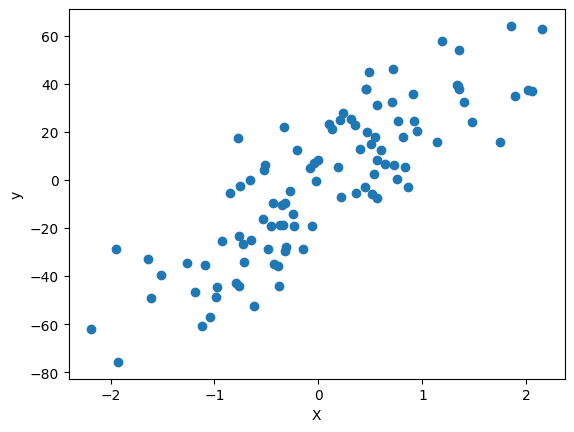

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=13
)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [2]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)

print("Weight:", lr.coef_[0])
print("Bias:", lr.intercept_)

Weight: 27.82809103252014
Bias: -2.29474455867698


In [3]:
m = -100
b = 100

learning_rate = 0.01

epochs = 10

In [5]:
all_m = []
all_b = []
all_cost = []

In [6]:
for epoch in range(epochs):

    for i in range(len(X)):

        # Random row selection
        idx = np.random.randint(0, len(X))

        x_i = X[idx]
        y_i = y[idx]

        # Prediction
        y_pred = m * x_i + b

        # Gradients
        dm = -2 * x_i * (y_i - y_pred)

        db = -2 * (y_i - y_pred)

        # Update
        m = m - learning_rate * dm
        b = b - learning_rate * db

        # Cost
        cost = (y_i - y_pred)**2

        all_m.append(m)
        all_b.append(b)
        all_cost.append(cost)

In [7]:
print("Final Weight =", m)
print("Final Bias =", b)

Final Weight = [28.68905141]
Final Bias = [-0.08189468]


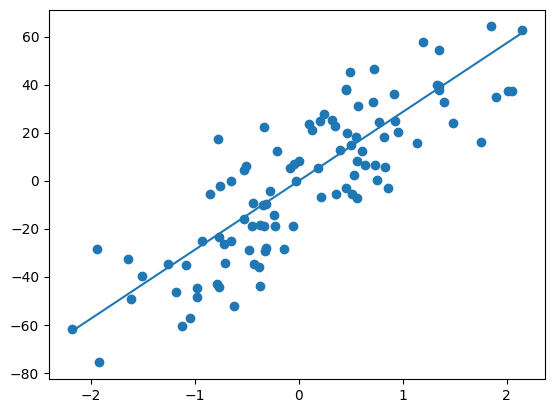

In [8]:
plt.scatter(X, y)

x_line = np.linspace(
    X.min(),
    X.max(),
    100
)

y_line = m*x_line + b

plt.plot(x_line, y_line)

plt.show()

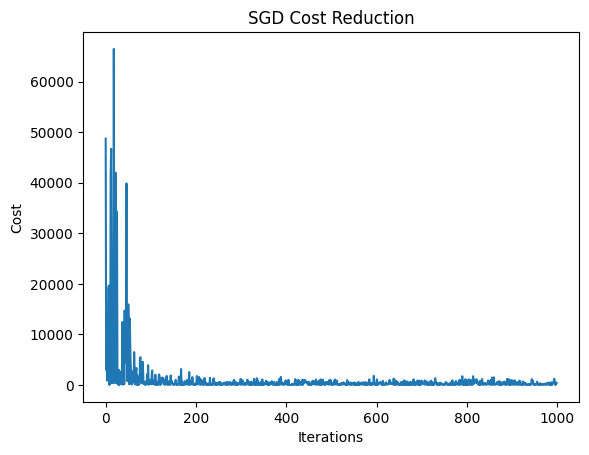

In [9]:
plt.plot(all_cost)

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.title("SGD Cost Reduction")

plt.show()

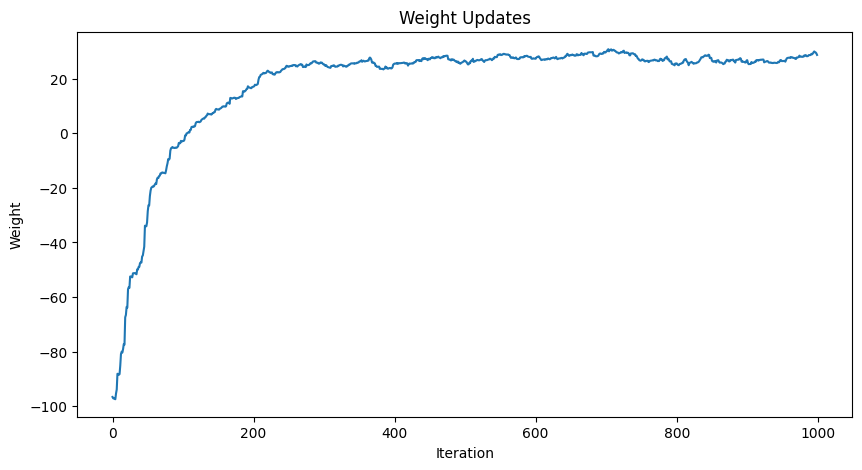

In [10]:
plt.figure(figsize=(10,5))

plt.plot(all_m)

plt.title("Weight Updates")

plt.xlabel("Iteration")
plt.ylabel("Weight")

plt.show()

In [11]:
t0 = 5
t1 = 50

def learning_rate(t):
    return t0/(t+t1)

In [13]:
lr = learning_rate(
    epoch*len(X) + i
)

# Mini Batch Gradient Descent

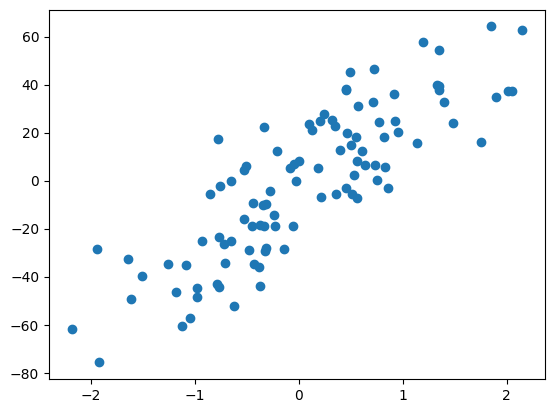

In [14]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=13
)

plt.scatter(X,y)
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X,y)

print("Actual Weight:",lr.coef_[0])
print("Actual Bias:",lr.intercept_)

Actual Weight: 27.82809103252014
Actual Bias: -2.29474455867698


In [16]:
m = -100
b = 100

learning_rate = 0.01

epochs = 50

batch_size = 10

In [17]:
all_m = []
all_b = []
all_cost = []

In [18]:
for epoch in range(epochs):

    # Shuffle dataset
    indices = np.random.permutation(len(X))

    X_shuffled = X[indices]
    y_shuffled = y[indices]

    # Create batches
    for i in range(0, len(X), batch_size):

        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        # Predictions
        y_pred = m * X_batch + b

        # Gradients
        dm = (-2/len(X_batch)) * np.sum(
            X_batch * (y_batch - y_pred)
        )

        db = (-2/len(X_batch)) * np.sum(
            y_batch - y_pred
        )

        # Update Parameters
        m = m - learning_rate * dm

        b = b - learning_rate * db

        # Batch Cost
        cost = np.mean(
            (y_batch - y_pred)**2
        )

        all_m.append(m)
        all_b.append(b)
        all_cost.append(cost)

In [19]:
print("Final Weight:",m)
print("Final Bias:",b)

Final Weight: 4.37128720203793
Final Bias: -4.68183724252249


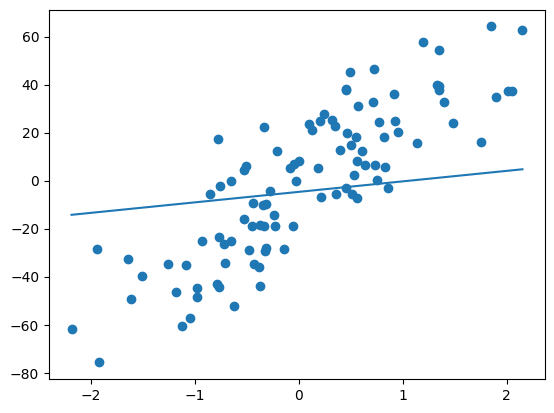

In [20]:
plt.scatter(X,y)

x_line = np.linspace(
    X.min(),
    X.max(),
    100
)

y_line = m*x_line + b

plt.plot(x_line,y_line)

plt.show()

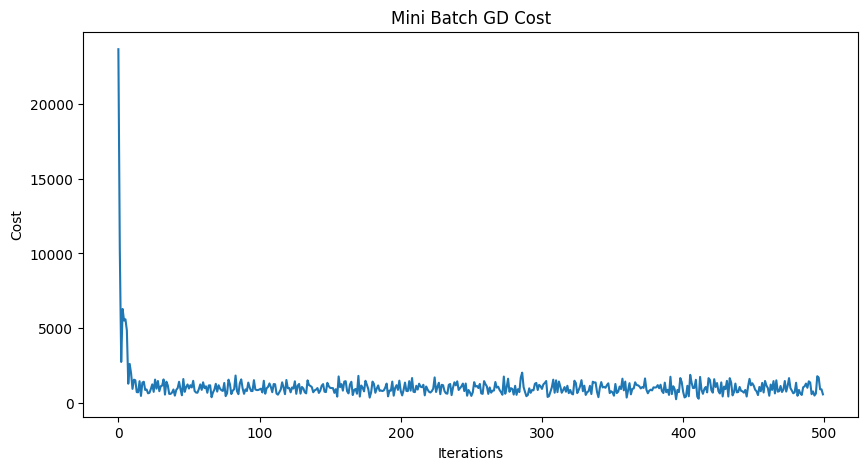

In [21]:
plt.figure(figsize=(10,5))

plt.plot(all_cost)

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.title("Mini Batch GD Cost")

plt.show()

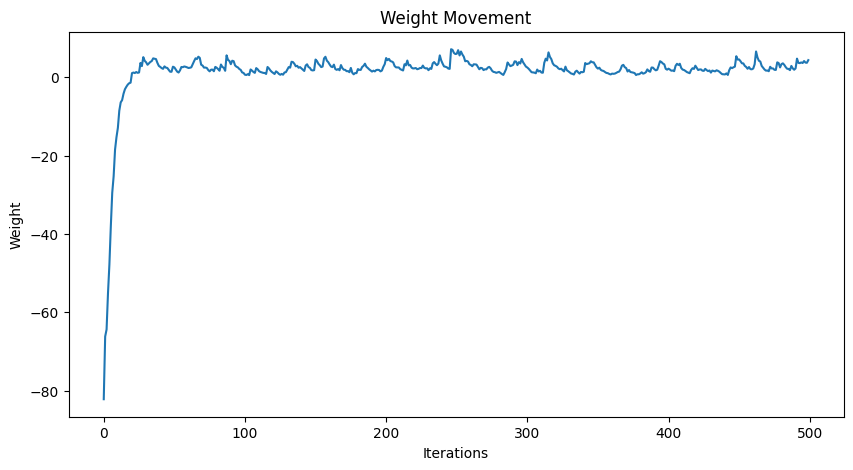

In [22]:
plt.figure(figsize=(10,5))

plt.plot(all_m)

plt.xlabel("Iterations")
plt.ylabel("Weight")

plt.title("Weight Movement")

plt.show()